# **ETL**

## Objectives

In this Jupyter Notebook, we will be following the ETL process on the raw dataset: `HR-Employee-Attrition-raw.csv`

The process will be as follows:
* **Extract**: We will load the dataset into a pandas DataFrame and perform an initial inspection of its structure, data types and quality.
* **Transform**: We will clean and standardise the dataset, change data types where necessary, remove any null values, and engineer new features.
* **Load**: Finally, we will export the cleaned DataFrame as a new CSV file, ready to be used in the next Jupyter Notebook - **EDA.ipynb**.

## Inputs

* The data input we need for this section is taken from Kaggle
* It is found in our project here: `datasets/raw-data/HR-Employee-Attrition-raw.csv`.
* It is a *synthetic dataset* made up of 1,470 rows of employee data

## Outputs

* At the end of this notebook, we created a new .csv file which has been cleaned and is ready for analysis.
* The relative path for this .csv file is: `datasets/cleaned-data/HR-Employee-Attrition-cleaned.csv`

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'/Users/elliebrawn/Documents/vscode-projects/Hackathon_2026_Group_1/jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'/Users/elliebrawn/Documents/vscode-projects/Hackathon_2026_Group_1'

---

# Import Packages and Libraries

I order to read `HR-Employee-Attrition-raw.csv` and perform the ETL pipeline process, we need to install the following libraries and packages:

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

---

# Load the Dataset

The first thing we need to do is load the raw dataset to make sure it works.

In [5]:
# Load the raw dataset
df = pd.read_csv("datasets/raw-data/HR-Employee-Attrition-raw.csv")

# Display the first few rows of the dataset to make sure the data has loaded correctly
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


---

# 1. Extract

In this first section, Extraction, we are looking to gain a baseline understanding of what our data looks like before we move on to cleaning and transforming.

We are using the acronym - **DISH** - to guide this process, where the letters stand for:

| Letter | Function / Attribute |
| ------ | ------- |
|**D**| `.describe`|
|**I**| `.info()`|
|**S**| `.shape`|
|**H**| `.head()`|

We will also use the following extraction steps:

| Function / Attribute |
| -----|
|`.dtypes`|
|`.isnull.sum()`|

## 1.1 Display the shape of the data

Using `.shape`, we are going to look at the shape (number of columns and rows)

In [6]:
# Display the shape of the dataset
print(f"Shape of the dataset: {df.shape}")

Shape of the dataset: (1470, 35)


The dataset contains 1470 rows and 35 columns.

## 1.2 Display the data types of each column

Now, we are going to inspect the data types for each column in our dataframe.

In [7]:
# Outline the data types of each column in the dataset
print(f"Data types of each column:\n{df.dtypes}")

Data types of each column:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel            

## 1.3 Display a summary of all columns in the dataset

In [8]:
# Use .info() to get a concise summary of the dataset, including the number of non-null entries
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

This method builds on what we already saw using `.shape` and `.dtypes`. We can see that the `Non-Null` counts are the same as the number of rows in the dataset, meaning we can assume there are **no missing values**. 

We'll check this out using `isnull().sum()`.

## 1.4 Check for Missing Values in the Dataset

In [9]:
## Check for null values in the dataset
print(f"Number of null values in each column:\n{df.isnull().sum()}")

Number of null values in each column:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
Ye

As we already guessed would happen (given what we saw with the `Non Null` counts), there are no missing values in this dataset that will require us to handle them. 

## 1.5 Display Summary Statistics for the Dataset

In this section, we will be using `.describe()` in order to get summary statistics for all of the numerical columns in our dataset. This will be a good initial test to see if there are any glaringly obvious anomalies that we might need to deal with in our **Transform** section.

In [10]:
# Use .describe() for summary statistics of the numerical columns in the dataset
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


Looking at this set of summary statistics, we have performed a quick lookover to see if we can spot any glaring anomalies. Obvious things to check:
* `Age`: is the minimum under 18? Are there any minors that we might need to address (given data protection laws)? **No, minim age is 18 and maximum age is 60, which feels like a suitable age range**.
* Minus Numbers: there should be no minus numbers in this set of statistics given what the columns relate to. **A quick look over says there are none**.

## 1.6 Check for duplicate values

We are going to check for duplicates now to see if any need to be dropped in the **Transform** section.

In [11]:
# Check for duplicate rows in the dataset
print(f"Number of duplicate rows in the dataset: {df.duplicated().sum()}")

Number of duplicate rows in the dataset: 0


Having performed `df.duplicated().sum()`, we can see that there are no duplicate rows that we will need to deal with.

---

# 2. Transform

In the **Transform** section, we will look to convert the raw dataset into a clean and well-structured dataset that can support the hypothesis testing and machine learning pipelines in the next two notebooks.

The first thing we will need to do is to create a copy of `df`. The reason for doing so is because we do not want to make any transformations to the original raw dataset.

In [12]:
# Create a copy of the original dataset to work with
df_etl = df.copy()

## 2.1 Categorical Column Cleaning

In this section, we need to look at our categorical column data to identify any issues with things like:
* inconsistent casing
* white space
* spelling mistakes

The easiest way to manage this is to create a variable of all `categorical_columns` so that we can loop through each one and print the unique values.

In [13]:
# Create a variable with all of the categorical columns in the dataset
categorical_columns = df_etl.select_dtypes(include=['object']).columns.tolist()

In [14]:
# Loop through each categorical column and print the unique values in that column
for column in categorical_columns:
    print("="*50)
    print(f"Column Name: {column}")
    print("="*50)
    print(f"Number of Unique Values: {df_etl[column].nunique()}\n")
    print(f"Unique Values: {df_etl[column].value_counts()}\n")

Column Name: Attrition
Number of Unique Values: 2

Unique Values: Attrition
No     1233
Yes     237
Name: count, dtype: int64

Column Name: BusinessTravel
Number of Unique Values: 3

Unique Values: BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Column Name: Department
Number of Unique Values: 3

Unique Values: Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

Column Name: EducationField
Number of Unique Values: 6

Unique Values: EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

Column Name: Gender
Number of Unique Values: 2

Unique Values: Gender
Male      882
Female    588
Name: count, dtype: int64

Column Name: JobRole
Number of Unique Values: 9

Unique Values: JobRole
Sales Executive              326


With a glance over all of these unique values, it appears that they are already cleaned. There are no spelling variations like "Sales Representative" vs "salesRepresentative".

In order to verify consistency, we will use `.strip()` to remove any whitespace.

In [15]:
# Remove whitespace from the values in the columns using .strip()
for column in categorical_columns:
    df_etl[column] = df_etl[column].str.strip()

# Check this has worked by printing the unique values for each categorical column again
for column in categorical_columns:
    print("="*50)
    print(f"Column Name: {column}")
    print("="*50)
    print(f"Number of Unique Values: {df_etl[column].nunique()}\n")
    print(f"Unique Values: {df_etl[column].value_counts()}\n")

Column Name: Attrition
Number of Unique Values: 2

Unique Values: Attrition
No     1233
Yes     237
Name: count, dtype: int64

Column Name: BusinessTravel
Number of Unique Values: 3

Unique Values: BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

Column Name: Department
Number of Unique Values: 3

Unique Values: Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

Column Name: EducationField
Number of Unique Values: 6

Unique Values: EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

Column Name: Gender
Number of Unique Values: 2

Unique Values: Gender
Male      882
Female    588
Name: count, dtype: int64

Column Name: JobRole
Number of Unique Values: 9

Unique Values: JobRole
Sales Executive              326


## 2.2 Handling Outliers

In this section, we are going to look at the outliers in each numerical column. We will first create a variable of all the numerical columns so that we can loop through each one.

In [16]:
# Create a variable for all numerical columns
numerical_columns = df_etl.select_dtypes(include=['int64', 'float64']).columns.tolist()

### 2.2.1 Interquartile Range Analysis

In [17]:
# Establish the Interquartile Range for all numerial columns in the dataset to identify potential outliers
for column in numerical_columns:
    Q1 = df_etl[column].quantile(0.25)
    Q3 = df_etl[column].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR
    upper_outliers = df_etl[df_etl[column] > upper_bound]
    lower_outliers = df_etl[df_etl[column] < lower_bound]
    print("="*60)
    print(f"INTERQUARTILE RANGE ANALYSIS FOR {column}")
    print("="*60)
    print(f"Q1 for {column}: {Q1}")
    print(f"Q3 for {column}: {Q3}")
    print(f"IQR for {column}: {IQR}")
    print("-"*60)
    print(f"Upper Bound for {column}: {upper_bound:.2f}")
    print(f"Lower Bound for {column}: {lower_bound:.2f}")
    print("-"*60)
    print(f"Number of Upper Outliers for {column}: {upper_outliers.shape[0]}")
    print(f"Number of Lower Outliers for {column}: {lower_outliers.shape[0]}")
    print()

INTERQUARTILE RANGE ANALYSIS FOR Age
Q1 for Age: 30.0
Q3 for Age: 43.0
IQR for Age: 13.0
------------------------------------------------------------
Upper Bound for Age: 62.50
Lower Bound for Age: 10.50
------------------------------------------------------------
Number of Upper Outliers for Age: 0
Number of Lower Outliers for Age: 0

INTERQUARTILE RANGE ANALYSIS FOR DailyRate
Q1 for DailyRate: 465.0
Q3 for DailyRate: 1157.0
IQR for DailyRate: 692.0
------------------------------------------------------------
Upper Bound for DailyRate: 2195.00
Lower Bound for DailyRate: -573.00
------------------------------------------------------------
Number of Upper Outliers for DailyRate: 0
Number of Lower Outliers for DailyRate: 0

INTERQUARTILE RANGE ANALYSIS FOR DistanceFromHome
Q1 for DistanceFromHome: 2.0
Q3 for DistanceFromHome: 14.0
IQR for DistanceFromHome: 12.0
------------------------------------------------------------
Upper Bound for DistanceFromHome: 32.00
Lower Bound for DistanceFro

By scrolling the the above cell, we can see the following numerical columns have outliers:
* `MonthlyIncome`: 114 outliers in the upper bound
* `NumCompaniesWorked`: 52 outliers in the upper bound
* `PerformanceRating`: 226 outliers in the upper bound
* `StockOptionLevel`: 85 outliers in the upper bound
* `TotalWorkingYears`: 63 outliers in the upper bound
* `TrainingTimesLastYear`: 184 outliers in the upper bound | 54 outliers in the lower bound
* `YearsAtCompany`: 104 outliers in the upper bound
* `YearsInCurrentRole`: 21 outliers in the upper bound
* `YearsSinceLastPromotion`: 107 outliers in the upper bound
* `YearsWithCurrManager`: 14 outliers in the upper bound

### 2.2.2 Assess Outliers with Boxplot and Histogram

We will address each one of these outliers separately by visualising them with a boxplot and histogram.

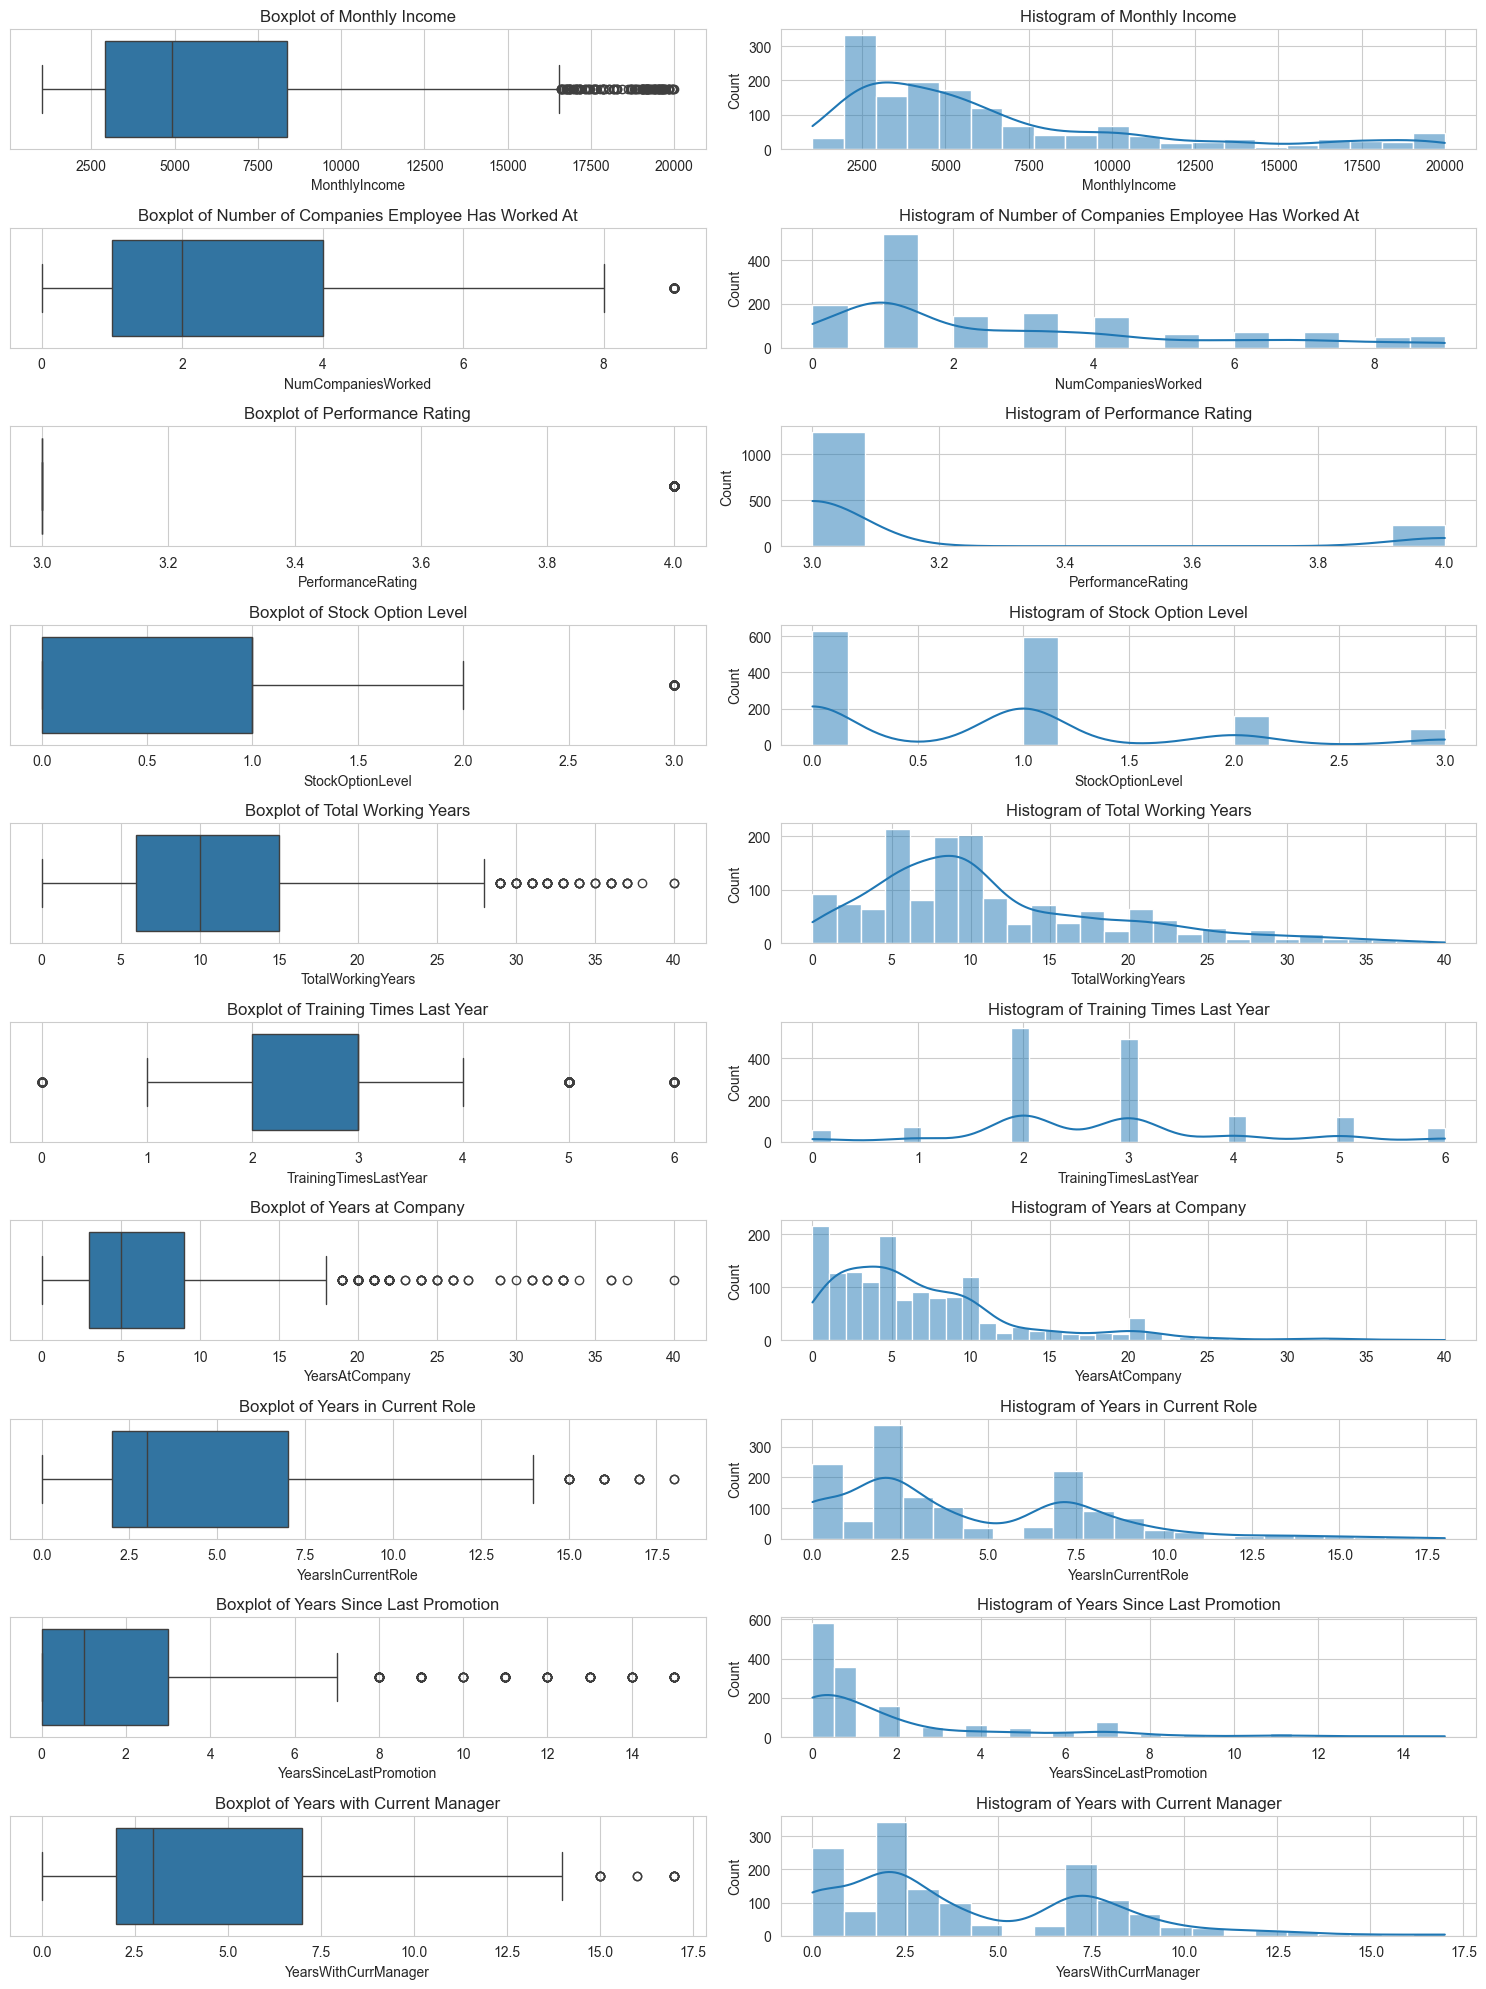

In [19]:
fig, axes = plt.subplots(nrows=10, ncols=2, figsize=(15, 20), tight_layout=True)

# Assess the outliers in MonthlyIncome column using a boxplot and histogram
sns.boxplot(x=df_etl["MonthlyIncome"], ax=axes[0,0])
axes[0,0].set_title("Boxplot of Monthly Income")

sns.histplot(df_etl["MonthlyIncome"], kde=True, ax=axes[0,1])
axes[0,1].set_title("Histogram of Monthly Income")

# Assess the outliers in NumCompaniesWorked column using a boxplot and histogram
sns.boxplot(x=df_etl["NumCompaniesWorked"], ax=axes[1,0])
axes[1,0].set_title("Boxplot of Number of Companies Employee Has Worked At")

sns.histplot(df_etl["NumCompaniesWorked"], kde=True, ax=axes[1,1])
axes[1,1].set_title("Histogram of Number of Companies Employee Has Worked At")

# Assess the outliers in PerformanceRating column using a boxplot and histogram
sns.boxplot(x=df_etl["PerformanceRating"], ax=axes[2,0])
axes[2,0].set_title("Boxplot of Performance Rating")

sns.histplot(df_etl["PerformanceRating"], kde=True, ax=axes[2,1])
axes[2,1].set_title("Histogram of Performance Rating")

# Assess the outliers in StockOptionLevel column using a boxplot and histogram
sns.boxplot(x=df_etl["StockOptionLevel"], ax=axes[3,0])
axes[3,0].set_title("Boxplot of Stock Option Level")

sns.histplot(df_etl["StockOptionLevel"], kde=True, ax=axes[3,1])
axes[3,1].set_title("Histogram of Stock Option Level")

# Assess the outliers in TotalWorkingYears column using a boxplot and histogram
sns.boxplot(x=df_etl["TotalWorkingYears"], ax=axes[4,0])
axes[4,0].set_title("Boxplot of Total Working Years")

sns.histplot(df_etl["TotalWorkingYears"], kde=True, ax=axes[4,1])
axes[4,1].set_title("Histogram of Total Working Years")

# Assess the outliers in TrainingTimesLastYear column using a boxplot and histogram
sns.boxplot(x=df_etl["TrainingTimesLastYear"], ax=axes[5,0])
axes[5,0].set_title("Boxplot of Training Times Last Year")

sns.histplot(df_etl["TrainingTimesLastYear"], kde=True, ax=axes[5,1])
axes[5,1].set_title("Histogram of Training Times Last Year")

# Assess the outliers in YearsAtCompany column using a boxplot and histogram
sns.boxplot(x=df_etl["YearsAtCompany"], ax=axes[6,0])
axes[6,0].set_title("Boxplot of Years at Company")

sns.histplot(df_etl["YearsAtCompany"], kde=True, ax=axes[6,1])
axes[6,1].set_title("Histogram of Years at Company")

# Assess the outliers in YearsInCurrentRole column using a boxplot and histogram
sns.boxplot(x=df_etl["YearsInCurrentRole"], ax=axes[7,0])
axes[7,0].set_title("Boxplot of Years in Current Role")

sns.histplot(df_etl["YearsInCurrentRole"], kde=True, ax=axes[7,1])
axes[7,1].set_title("Histogram of Years in Current Role")

# Assess the outliers in YearsSinceLastPromotion column using a boxplot and histogram
sns.boxplot(x=df_etl["YearsSinceLastPromotion"], ax=axes[8,0])
axes[8,0].set_title("Boxplot of Years Since Last Promotion")

sns.histplot(df_etl["YearsSinceLastPromotion"], kde=True, ax=axes[8,1])
axes[8,1].set_title("Histogram of Years Since Last Promotion")

# Assess the outliers in YearsWithCurrManager column using a boxplot and histogram
sns.boxplot(x=df_etl["YearsWithCurrManager"], ax=axes[9,0])
axes[9,0].set_title("Boxplot of Years with Current Manager")

sns.histplot(df_etl["YearsWithCurrManager"], kde=True, ax=axes[9,1])
axes[9,1].set_title("Histogram of Years with Current Manager")

plt.show()

`PerformanceRating` was a particularly odd presentation for a boxplot and histogram. By calling the `.value_counts()` we understood better why: of the 1470 people in the dataset, all have been ranked as either a `3` or a `4` with regards to their performance.

In [20]:
df_etl["PerformanceRating"].value_counts()

PerformanceRating
3    1244
4     226
Name: count, dtype: int64

### 2.2.3 Summary: Should We Delete the Outliers?

We should not be removing outliers automatically. In this HR dataset, extreme values may represent important populations for analysis:

* Highly experienced employees
* Senior employees with high income
* Employees with long tenure
* Employees who have worked for many companies
* Employees with unusually long commutes

An IQR outlier is a statistical observation, not necessarily a data error.

Also, we must look at the quantity of values that are classed as outliers. In many variables, these there are more than 100 outliers and in a dataset of only 1470 employees to start with, this would represent a large proportion of data and potential analysis lost if we were to remove them.

## 2.3 Feature Engineering

### 2.3.1 Drop Columns

In the process of analysing the dataset, as a team we noticed that there were three columns that appeared to hold no additional information. We had a discussion where we weighed up keeping the data intact vs performing feature selection to improve a machine learning model's performance (and removing noisy data). 

Below, we will outline which columns we felt were appropriate to delete and why.

In [21]:
# Show unique values for the column Over18
df_etl["Over18"].value_counts()

Over18
Y    1470
Name: count, dtype: int64

In [22]:
# Show unique values for the EmployeeCount column
df_etl["EmployeeCount"].value_counts()

EmployeeCount
1    1470
Name: count, dtype: int64

In [23]:
# Show unique values for the StandardHours column
df_etl["StandardHours"].value_counts()

StandardHours
80    1470
Name: count, dtype: int64

In each of these three columns, there is only 1 unique value. These columns will therefore add unnecessary noise to our analysis without offering any real statistical insights.

In [24]:
# Print the shape of the dataset
print(f"Shape of the dataset: {df_etl.shape}\n")

# # Drop the columns Over18, EmployeeCount and StandardHours as they are not useful for analysis
df_etl = df_etl.drop(columns=["Over18", "EmployeeCount", "StandardHours"])

# Print the shape of the dataset after dropping the columns
print(f"Shape of the dataset after dropping columns: {df_etl.shape}\n")

# Print the column names of the dataset after dropping the columns
print(f"Column names of the dataset after dropping columns: {df_etl.columns.tolist()}")

Shape of the dataset: (1470, 35)

Shape of the dataset after dropping columns: (1470, 32)

Column names of the dataset after dropping columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


As we can see, we have removed three columns (35 columns --> 32 columns).

### 2.3.2 Create Columns

#### Age Bracket

We want to create age brackets to help with analysis. Firstly, we need to check the range of ages to see what the bins need to go up to.

In [25]:
# Find the minimum age
print(f"Minimum Age in the dataset: {df_etl['Age'].min()}")

# Find the maximum age
print(f"Maximum Age in the dataset: {df_etl['Age'].max()}")

Minimum Age in the dataset: 18
Maximum Age in the dataset: 60


Now we know the range of ages, we are going to create the following bins: 

`"18-25", "26-35", "36-45", "46-55", "56-65"`

In [26]:
# Create the AgeBracket bins
AgeBracket_bins = [17, 25, 35, 45, 55, 65]

# Create the AgeBracket labels
AgeBracket_labels = ["18-25", "26-35", "36-45", "46-55", "56-65"]

# Create new AgeBracket column in the dataset using pd.cut() to categorise the Age column into the defined bins and labels
df_etl["AgeBracket"] = pd.cut(df_etl["Age"], bins=AgeBracket_bins, labels=AgeBracket_labels, right=True)

# Make sure the AgeBracket column is listed as a categorical column in the dataset
df_etl["AgeBracket"] = pd.Categorical(df_etl["AgeBracket"], categories=AgeBracket_labels, ordered=True)

# Check that the data is now categorical by using .dtypes
print(f"Data type of the new AgeBracket column:{df_etl['AgeBracket'].dtypes}\n")

# Print the .value_counts() of the new AgeBracket column to see how many employees fall into each age bracket
print(f"Value counts of the new AgeBracket column:\n{df_etl['AgeBracket'].value_counts(sort=False)}")

Data type of the new AgeBracket column:category

Value counts of the new AgeBracket column:
AgeBracket
18-25    123
26-35    606
36-45    468
46-55    226
56-65     47
Name: count, dtype: int64


#### Tenure

In this section, we are going to create a new column to create categories for the number of years an employee has been at a company. As with `Age`, we need to check the range of `YearsAtCompany` to see what the bins need to go up to.

In [27]:
# Find the minimum years at company
print(f"Minimum YearsAtCompany in the dataset: {df_etl['YearsAtCompany'].min()}")

# Find the maximum years at company
print(f"Maximum YearsAtCompany in the dataset: {df_etl['YearsAtCompany'].max()}")

Minimum YearsAtCompany in the dataset: 0
Maximum YearsAtCompany in the dataset: 40


Now we know the range, we are going to create the following bins: 

`"New Hire (0-2)", "Early Career (3-5)", "Established (6-10)", "Experienced (11-20)", "Long-Tenured (21+)"`

In [28]:
# Create the YearsAtCompany bins
Tenure_bins = [-1, 2, 5, 10, 20, 40]

# Create the YearsAtCompany labels
Tenure_labels = ["New Hire (0-2)", "Early Career (3-5)", "Established (6-10)", "Experienced (11-20)", "Long-Tenured (21+)"]

# Create new Tenure column in the dataset using pd.cut() to categorise the YearsAtCompany column into the defined bins and labels
df_etl["Tenure"] = pd.cut(df_etl["YearsAtCompany"], bins=Tenure_bins, labels=Tenure_labels, right=True)

# Make sure the Tenure column is listed as a categorical column in the dataset
df_etl["Tenure"] = pd.Categorical(df_etl["Tenure"], categories=Tenure_labels, ordered=True)

# Check that the data is now categorical by using .dtypes
print(f"Data type of the new Tenure column:{df_etl['Tenure'].dtypes}\n")

# Print the .value_counts() of the new Tenure column to see how many employees fall into each age bracket
print(f"Value counts of the new Tenure column:\n{df_etl['Tenure'].value_counts(sort=False)}")

Data type of the new Tenure column:category

Value counts of the new Tenure column:
Tenure
New Hire (0-2)         342
Early Career (3-5)     434
Established (6-10)     448
Experienced (11-20)    180
Long-Tenured (21+)      66
Name: count, dtype: int64


#### Annual Income

We are going to create a new column for `AnnualIncome` (`MonthlyIncome *12`).

In [29]:
# Create AnnualIncome column by multiplying MonthlyIncome by 12
df_etl["AnnualIncome"] = df_etl["MonthlyIncome"] * 12

# Sanity Check AnnualIncome vs MonthlyIncome
df_etl[["MonthlyIncome", "AnnualIncome"]].describe()

,MonthlyIncome,AnnualIncome
count,1470.000000,1470.000000
mean,6502.931293,78035.175510
std,4707.956783,56495.481397
min,1009.000000,12108.000000
25%,2911.000000,34932.000000
50%,4919.000000,59028.000000
75%,8379.000000,100548.000000
max,19999.000000,239988.000000


Looking at these, the numbers appear to check out:

`min`: 1009 * 12 = 12108

`max`: 19999 * 12 = 239988

`mean`: 6502.931293 * 12 = 78035.175510

#### Satisfaction Score

We want to make a composite feature made up of all of the individual satisfaction-related columns:
* `EnvironmentSatisfaction` (1-4)
* `JobSatisfaction` (1-4)
* `RelationshipSatisfaction` (1-4)
* `WorkLifeBalance` (1-4)

In [30]:
# Create a variable for the SatisfactionScore columns
satisfaction_columns = ["EnvironmentSatisfaction", "JobSatisfaction", "RelationshipSatisfaction", "WorkLifeBalance"]

# Create a new column called SatisfactionScore that is the average of the four satisfaction columns
df_etl["SatisfactionScore"] = df_etl[satisfaction_columns].mean(axis=1) # Make sure to use axis=1 to calculate ACROSS columns for each row

# Sanity check the new SatisfactionScore column by using .describe() to get summary statistics
df_etl["SatisfactionScore"].describe()


count    1470.000000
mean        2.730952
std         0.505815
min         1.000000
25%         2.500000
50%         2.750000
75%         3.000000
max         4.000000
Name: SatisfactionScore, dtype: float64

#### Confirm Columns Created

In [31]:
# Use .head() to display the first few rows of the last columns in the dataset to make sure the new columns have been added correctly
df_etl.iloc[:, -5:].head()

,YearsWithCurrManager,AgeBracket,Tenure,AnnualIncome,SatisfactionScore
0,5,36-45,Established (6-10),71916,2.00
1,7,46-55,Established (6-10),61560,3.00
2,0,36-45,New Hire (0-2),25080,3.00
3,0,26-35,Established (6-10),34908,3.25
4,2,26-35,New Hire (0-2),41616,2.50


### 2.3.3 Encode

In this section, we will encode the variable `Attrition` into a new column `AttritionBinary`. This will make it easier for classification modelling in **ML.ipynb**.

In [32]:
# Map Attrition = Yes as 1 and Attrition = No as 0
df_etl["AttritionBinary"] = df_etl["Attrition"].map({"Yes": 1, "No": 0})

# Check the AttritionBinary values vs the original Attrition column to make sure the mapping has worked correctly
df_etl[["AttritionBinary", "Attrition"]].value_counts()

AttritionBinary  Attrition
0                No           1233
1                Yes           237
Name: count, dtype: int64

In [33]:
# Check the shape of the new dataset after feature engineering
print(f"Shape of the feature engineered dataset: {df_etl.shape}\n")

# Check the columns of the new dataset after feature engineering
print(f"Columns of the feature engineered dataset: {df_etl.columns.tolist()}\n")

# Use .head() to display the first few rows of the columns in the dataset to make sure the new columns have been added correctly
df_etl.head()


Shape of the feature engineered dataset: (1470, 37)

Columns of the feature engineered dataset: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'AgeBracket', 'Tenure', 'AnnualIncome', 'SatisfactionScore', 'AttritionBinary']



,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeNumber,EnvironmentSatisfaction,...,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,AgeBracket,Tenure,AnnualIncome,SatisfactionScore,AttritionBinary
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,2,...,1,6,4,0,5,36-45,Established (6-10),71916,2.00,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,2,3,...,3,10,7,1,7,46-55,Established (6-10),61560,3.00,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,4,...,3,0,0,0,0,36-45,New Hire (0-2),25080,3.00,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,5,4,...,3,8,7,3,0,26-35,Established (6-10),34908,3.25,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,7,1,...,3,2,2,2,2,26-35,New Hire (0-2),41616,2.50,0


---

# 3. Load

Now that we have completed all the ETL pipeline steps, we are going to load our new cleaned dataset to the folder `datasets/cleaned-data`.

In [ ]:
df_etl.to_csv("datasets/cleaned-data/HR-Employee-Attrition-cleaned.csv", index=False)

---

# 4. Conclusion

In this notebook, we carried out the ETL process on the raw HR employee attrition dataset and it is now ready to be used in **EDA.ipynb**.
* We loaded the dataset and displayed summary statistics.
* We analysed the categorical columns and looked through value counts to ensure there were no inconsistencies with spelling or whitespace (removed with `.strip`). 
* We made decisions regarding the outliers in each of the numerical columns (using IQR analysis and visualisations), ultimately deciding that the values they would add meant that we should keep them in.
* Finally, we encoded the column `Attrition` because we will be using this as the target in our machine learning section.

---